# <font color="brown">Credit Default Prediction with an sklearn Pipeline </font>

## <font color = "brown">Problem Statement </font>

### <font color="blue"> Context

The `Decision Trees` case study built a credit-default classifier on this same customer dataset by
manually one-hot encoding every categorical column with `pd.get_dummies`, training a Decision
Tree, and tuning it with `GridSearchCV`. That's the normal way to build and select a model. Once a
model is selected, though, "encode by hand, then train" is still two separate steps a real
deployment has to remember to repeat, in order, on every new batch of raw data. This case study
builds a model the normal way first, then shows what changes when that finished model is packaged
into a single `Pipeline` object.

### <font color="blue"> Objective

- Build and tune a Decision Tree the traditional way: encode manually, train, then use
  `GridSearchCV` to select the best hyperparameters.
- Only after a final model is selected, wrap the encoding step and the tuned model together into
  one `Pipeline` using `make_pipeline`.
- Confirm the packaged pipeline reproduces the selected model's result exactly.

### <font color="blue"> Data Dictionary

Same dataset as the `Decision Trees` case study (`default_on_payment.csv`, 5,000 customers,
copied into this folder): credit history, account status, loan amount, employment, and
demographic fields, with `Default_On_Payment` (1 = defaulted, 0 = repaid) as the target.

## <font color="brown"> Importing Necessary Libraries</font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline

## <font color="brown"> Reading the Data</font>

In [2]:
df = pd.read_csv("default_on_payment.csv")
df = df.drop(columns=["Customer_ID"])
print(df.shape)
df.head()

(5000, 21)


,Status_Checking_Acc,Duration_in_Months,Credit_History,Purposre_Credit_Taken,Credit_Amount,Savings_Acc,Years_At_Present_Employment,Inst_Rt_Income,Marital_Status_Gender,Other_Debtors_Guarantors,...,Property,Age,Other_Inst_Plans,Housing,Num_CC,Job,Dependents,Telephone,Foreign_Worker,Default_On_Payment
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


## <font color="brown"> Step 1: Build a Decision Tree Model</font>

The traditional way: encode the categorical columns by hand with `pd.get_dummies`, then train a
Decision Tree on the encoded table.

In [3]:
X = df.drop(columns=["Default_On_Payment"])
y = df["Default_On_Payment"]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)
print(X_encoded.shape)
X_encoded.head()

(5000, 48)


C:\Users\yoges\AppData\Local\Temp\ipykernel_24592\2390166034.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns.tolist()


,Duration_in_Months,Credit_Amount,Inst_Rt_Income,Current_Address_Yrs,Age,Num_CC,Dependents,Status_Checking_Acc_A12,Status_Checking_Acc_A13,Status_Checking_Acc_A14,...,Property_A124,Other_Inst_Plans _A142,Other_Inst_Plans _A143,Housing_A152,Housing_A153,Job_A172,Job_A173,Job_A174,Telephone_A192,Foreign_Worker_A202
0,6,1169,4,4,67,2,1,0,0,0,...,0,0,1,1,0,0,1,0,1,0
1,48,5951,2,2,22,1,1,1,0,0,...,0,0,1,1,0,0,1,0,0,0
2,12,2096,2,3,49,1,2,0,0,1,...,0,0,1,1,0,1,0,0,0,0
3,42,7882,2,4,45,1,2,0,0,0,...,0,0,1,0,1,0,1,0,0,0
4,24,4870,3,4,53,2,2,0,0,0,...,1,0,1,0,1,0,1,0,0,0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (3500, 48)  Test: (1500, 48)


In [5]:
base_dtree = DecisionTreeClassifier(random_state=0)
base_dtree.fit(X_train, y_train)

pred_train = base_dtree.predict(X_train)
pred_test = base_dtree.predict(X_test)

print("Train recall:", round(recall_score(y_train, pred_train), 3))
print("Test recall: ", round(recall_score(y_test, pred_test), 3))

Train recall: 1.0
Test recall:  0.834


A fully grown tree memorises the training data (100% train recall) but generalises worse to the
test set (~83% test recall), the classic overfitting pattern already seen in `Decision Trees`.

## <font color="brown"> Step 2: Hyperparameter Tuning with GridSearchCV</font>

Search over `max_depth` and `min_samples_leaf`, scoring by recall, to find a tree that
generalises better than the unrestricted base tree above:

In [6]:
param_grid = {
    "max_depth": [3, 4, 5, 6, 7],
    "min_samples_leaf": [5, 10, 20, 30],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=0), param_grid, scoring="recall", cv=5, n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': 7, 'min_samples_leaf': 5}


## <font color="brown"> Step 3: Select the Best Model</font>

In [7]:
selected_model = grid_search.best_estimator_

pred_train_tuned = selected_model.predict(X_train)
pred_test_tuned = selected_model.predict(X_test)

comparison = pd.DataFrame({
    "Train Recall": [
        recall_score(y_train, pred_train),
        recall_score(y_train, pred_train_tuned),
    ],
    "Test Recall": [
        recall_score(y_test, pred_test),
        recall_score(y_test, pred_test_tuned),
    ],
}, index=["Base Tree", "Selected (Tuned) Tree"]).round(3)
comparison

,Train Recall,Test Recall
Base Tree,1.000,0.834
Selected (Tuned) Tree,0.756,0.782


`grid_search.best_estimator_` is the model actually selected for deployment: fewer than 100%
train recall now, but a much smaller train-test gap than the base tree, a more trustworthy result
on data it hasn't seen. This is the model we now package into a pipeline.

## <font color="brown"> Step 4: Create a Pipeline for the Selected Model</font>

So far, `X_train`/`X_test` were manually encoded *before* any of the modeling above. Anyone
reusing `selected_model` on new, raw data has to remember to repeat that exact encoding step
first, in the exact same way, or predictions will be wrong (or crash). A `Pipeline` removes that
by bundling the encoding and the selected model into one object with one `.fit()`/`.predict()`:

In [8]:
preprocessor = ColumnTransformer(
    transformers=[("encode", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)],
    remainder="passthrough",
)

final_pipeline = make_pipeline(
    preprocessor,
    DecisionTreeClassifier(random_state=0, **grid_search.best_params_),
)
final_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encode', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float,

Note the pipeline is trained on the **raw** `X` (with the original, un-encoded categorical
columns), split fresh here, not on `X_encoded`, that's the whole point: the pipeline does its own
encoding internally, so it needs to see raw data as input, exactly what new data would look like:

In [9]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.3, random_state=42
)

final_pipeline.fit(X_train_raw, y_train_raw)

pred_train_pipe = final_pipeline.predict(X_train_raw)
pred_test_pipe = final_pipeline.predict(X_test_raw)

print("Train recall:", round(recall_score(y_train_raw, pred_train_pipe), 3))
print("Test recall: ", round(recall_score(y_test_raw, pred_test_pipe), 3))

Train recall: 0.756
Test recall:  0.782


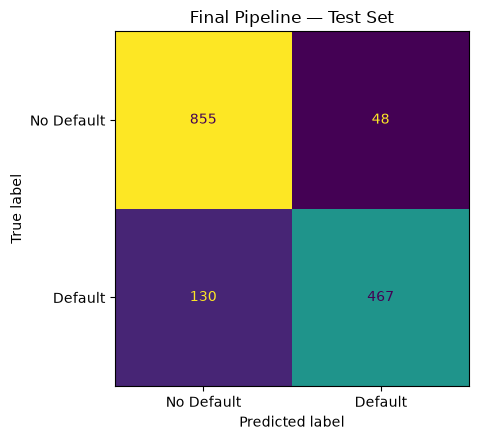

In [10]:
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test_raw, pred_test_pipe, display_labels=["No Default", "Default"], ax=ax, colorbar=False
)
ax.set_title("Final Pipeline — Test Set")
plt.tight_layout()
plt.show()

**Exact match**: 75.6% train recall / 78.2% test recall, identical to `selected_model` evaluated
on the manually-encoded data. The pipeline, fit directly on raw, un-encoded rows, reproduces the
selected model bit-for-bit, confirming the packaging step changed nothing about the model's
behaviour.

## <font color="brown"> Business Insights and Recommendations</font>

- **Packaging into a pipeline changed nothing about the result.** The final pipeline's recall
  (75.6% train / 78.2% test) exactly matches `selected_model`'s recall on the manually-encoded
  data. The pipeline is not a different model, it's the same selected model plus its encoding
  step, bundled into one object.

- **What the pipeline actually buys you is at prediction time.** `selected_model` only accepts
  already-encoded input, whoever uses it later has to remember to reproduce the exact same
  `pd.get_dummies` call, with the same columns, in the same order, before every prediction.
  `final_pipeline` accepts the same raw columns the dataset started with and does the encoding
  itself, there's no separate step to forget or get wrong.

- **The right order to learn this in**: build and tune a model the normal way first (as
  `Decision Trees` did, and as Steps 1-3 here repeat), understand what the model needs and why.
  Only once a specific model is selected does it make sense to package it into a pipeline, that
  packaging is a deployment/reuse convenience on top of a modeling decision already made, not a
  substitute for making that decision.

- **Recommendation**: after selecting a final model through the usual build-tune-select workflow,
  wrap its exact preprocessing and hyperparameters into a `Pipeline` before saving or deploying it,
  so the model and the steps it depends on travel together as one reusable object.